In [7]:
import simpy
import numpy as np
import pandas as pd

def run_simulation(n, cantidad_reparadores, media_fallos, media_reparacion, tiempo_simulacion, random_seed=42):
    
    np.random.seed(random_seed)
    
    robots_operativos = []     # (tiempo, cantidad de robots operativos)
    reparadores_ocupados = []   # (tiempo, cantidad de reparadores ocupados)
    tiempo_reparacion_sims = []  # Tiempos que tarda cada reparación

    def proceso(env, reparadores):
        nonlocal count
        while True:
            # Tiempo hasta la falla usando la distribución exponencial
            tiempo_fracaso = np.random.exponential(media_fallos)
            yield env.timeout(tiempo_fracaso)
            
            breakdown_time = env.now
            count -= 1  # Se reduce el conteo de robots operativos
            robots_operativos.append((env.now, count))
            
            # Solicitar un reparador
            with reparadores.request() as req:
                yield req
                ocupado = cantidad_reparadores - reparadores.count
                reparadores_ocupados.append((env.now, ocupado))
                # Tiempo de reparación
                repair_duration = np.random.exponential(media_reparacion)
                yield env.timeout(repair_duration)
            
            ocupado = cantidad_reparadores - reparadores.count
            reparadores_ocupados.append((env.now, ocupado))
            count += 1
            robots_operativos.append((env.now, count))
            tiempo_reparacion_sims.append(env.now - breakdown_time)

    env = simpy.Environment()
    reparadores = simpy.Resource(env, capacity=cantidad_reparadores)
    
    count = n
    robots_operativos.append((0, count))

    for i in range(n):
        env.process(proceso(env, reparadores))
        
    env.run(until=tiempo_simulacion)
    
    robots_operativos.sort(key=lambda x: x[0])
    total_operational = 0
    prev_time, prev_count = robots_operativos[0]
    for time, cnt in robots_operativos[1:]:
        delta = time - prev_time
        total_operational += prev_count * delta
        prev_time, prev_count = time, cnt
 
    delta = tiempo_simulacion - prev_time
    total_operational += prev_count * delta
    avg_operational = total_operational / tiempo_simulacion

    avg_repair_time = np.mean(tiempo_reparacion_sims) if tiempo_reparacion_sims else 0

    reparadores_ocupados.sort(key=lambda x: x[0])
    idle_time = 0
    prev_time, prev_busy = reparadores_ocupados[0]
    for time, busy in reparadores_ocupados[1:]:
        delta = time - prev_time
        if prev_busy < cantidad_reparadores:
            idle_time += delta
        prev_time, prev_busy = time, busy
    delta = tiempo_simulacion - prev_time
    if prev_busy < cantidad_reparadores:
        idle_time += delta
    percentage_idle = (idle_time / tiempo_simulacion) * 100

    return {
        "avg_operational": avg_operational,
        "avg_repair_time": avg_repair_time,
        "percentage_idle": percentage_idle,
        "n": n,
        "cantidad_reparadores": cantidad_reparadores,
        "media_fallos": media_fallos,
        "media_reparacion": media_reparacion
    }

experiments = [
    {"n": 5, "cantidad_reparadores": 2, "media_fallos": 10, "media_reparacion": 3}, 
    {"n": 5, "cantidad_reparadores": 1, "media_fallos": 30, "media_reparacion": 3}, 
    {"n": 5, "cantidad_reparadores": 2, "media_fallos": 10, "media_reparacion": 4},  
]

tiempo_simulacion = 100_000
num_replicas = 30  

resultados = []

for exp in experiments:
    for replica in range(num_replicas):
        res = run_simulation(
            exp["n"], 
            exp["cantidad_reparadores"], 
            exp["media_fallos"],
            exp["media_reparacion"], 
            tiempo_simulacion, 
            random_seed=replica  
        )
        resultados.append({
            **res,
            "Experimento": str(exp),  
            "Réplica": replica
        })

df = pd.DataFrame(resultados)
df


,avg_operational,avg_repair_time,percentage_idle,n,cantidad_reparadores,media_fallos,media_reparacion,Experimento,Réplica
0,3.714915,3.455924,74.363291,5,2,10,3,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",0
1,3.713006,3.469414,74.216228,5,2,10,3,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",1
2,3.709182,3.477614,74.941749,5,2,10,3,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",2
3,3.692297,3.530575,75.253832,5,2,10,3,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",3
4,3.710638,3.497524,74.746107,5,2,10,3,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",4
...,...,...,...,...,...,...,...,...,...
85,3.367724,4.906266,82.962838,5,2,10,4,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",25
86,3.330965,5.028821,83.196544,5,2,10,4,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",26
87,3.349409,4.962927,83.478909,5,2,10,4,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",27
88,3.342205,4.957252,83.469510,5,2,10,4,"{'n': 5, 'cantidad_reparadores': 2, 'media_fal...",28


Resultado ANOVA para robots operativos:
F-value: 71431.84, p-value: 0.0000

Diferencias significativas entre experimentos (Post-Hoc):
                                                                        Multiple Comparison of Means - Tukey HSD, FWER=0.05                                                                        
                                    group1                                                                         group2                                     meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
{'n': 5, 'cantidad_reparadores': 1, 'media_fallos': 30, 'media_reparacion': 3} {'n': 5, 'cantidad_reparadores': 2, 'media_fallos': 10, 'media_reparacion': 3}  -0.6525   0.0  -0.659 -0.6459   True
{'n': 5, 'cantidad_reparadores': 1, 'media_fallos': 30, 'media_reparacion': 3} {'n

<Figure size 1000x600 with 0 Axes>

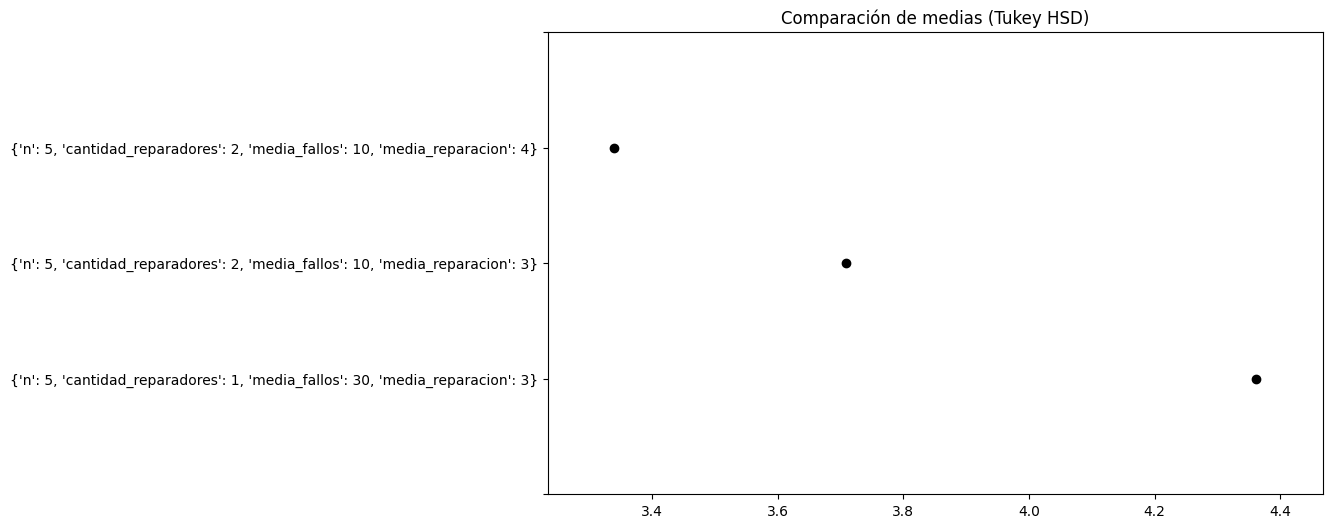

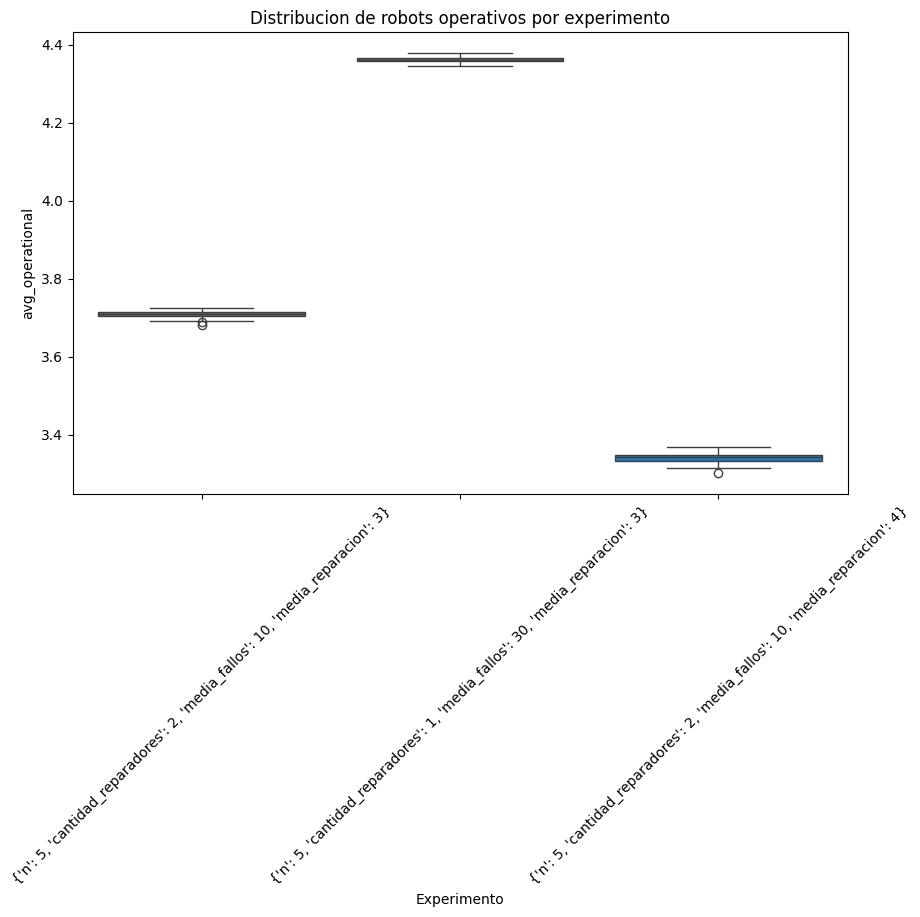

In [8]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns

# ANOVA
groups = [df[df['Experimento'] == str(exp)]['avg_operational'] for exp in experiments]
f_value, p_value = stats.f_oneway(*groups)

print(f"Resultado ANOVA para robots operativos:")
print(f"F-value: {f_value:.2f}, p-value: {p_value:.4f}")

# Post-Hoc (Tukey HSD) si p-value < 0.05
if p_value < 0.05:
    print("\nDiferencias significativas entre experimentos (Post-Hoc):")
    tukey = pairwise_tukeyhsd(
        endog=df['avg_operational'],
        groups=df['Experimento'],
        alpha=0.05
    )
    print(tukey.summary())
    
    plt.figure(figsize=(10, 6))
    tukey.plot_simultaneous()
    plt.title("Comparación de medias (Tukey HSD)")
    plt.show()
else:
    print("\nNo hay diferencias significativas entre experimentos")

plt.figure(figsize=(10, 6))
sns.boxplot(x='Experimento', y='avg_operational', data=df)
plt.title("Distribucion de robots operativos por experimento")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Calcular Intervalos de confiaanza
alpha = 0.05  # 95% de confianza
t_critical = stats.t.ppf(1 - alpha/2, df=num_replicas-1) 

grouped = df.groupby("Experimento")["avg_operational"].agg(
    media = "mean",
    desviacion = "std",
    n = "count"
).reset_index()

grouped["error_estandar"] = grouped["desviacion"] / np.sqrt(grouped["n"])
grouped["margen_error"] = t_critical * grouped["error_estandar"]
grouped["ci_inferior"] = grouped["media"] - grouped["margen_error"]
grouped["ci_superior"] = grouped["media"] + grouped["margen_error"]

print(grouped[["Experimento", "media", "ci_inferior", "ci_superior"]])

                                         Experimento     media  ci_inferior  \
0  {'n': 5, 'cantidad_reparadores': 1, 'media_fal...  4.361811     4.358454   
1  {'n': 5, 'cantidad_reparadores': 2, 'media_fal...  3.709343     3.705708   
2  {'n': 5, 'cantidad_reparadores': 2, 'media_fal...  3.340178     3.335431   

   ci_superior  
0     4.365169  
1     3.712977  
2     3.344925  
